In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import joblib

from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import classification_report, roc_auc_score

from src.data_loader         import load_raw_data, basic_profiling
from src.feature_engineering import build_viralidad, build_features, get_feature_columns
from src.preprocessing       import build_preprocessor, split_data, save_preprocessor

# IMPORTACIONES ACTUALIZADAS
from src.modeling            import get_base_models, tune_hyperparameters, cross_validate_models, train_and_save
from src.evaluation          import (
    evaluate_on_test, plot_confusion_matrices, plot_roc_curves,
    plot_feature_importance, plot_cv_comparison, plot_metrics_heatmap, save_tuning_report
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000
RAW_PATH     = '../data/raw/global_youtube_creator_data_large.csv'
FIGURES_DIR  = '../reports/figures'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


In [2]:
import os, pickle
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(''))
while PROJECT_ROOT.name != 'Proyecto_Final_ML':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
print("Working dir:", PROJECT_ROOT)

# Cargar artefactos de Fase 3
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase3_artifacts.pkl', 'rb') as f:
    a3 = pickle.load(f)

X_test_proc        = a3['X_test_proc']
y_test             = a3['y_test']
feature_names_proc = a3['feature_names_proc']

# Cargar artefactos de Fase 4
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase4_artifacts.pkl', 'rb') as f:
    a4 = pickle.load(f)

trained_models = a4['trained_models']
best_models    = a4['best_models']
cv_results     = a4['cv_results']

print("Todo cargado para Fase 5")

Working dir: c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML
Todo cargado para Fase 5


---
# FASE 5 | EVALUACION (Evaluation)
---

## 5.1 Metricas en el conjunto de prueba

In [3]:
test_results = evaluate_on_test(trained_models, X_test_proc, y_test.values)


  Regresion Logistica
              precision    recall  f1-score   support

    No Viral       0.62      0.61      0.61      9999
       Viral       0.61      0.62      0.62      9999

    accuracy                           0.62     19998
   macro avg       0.62      0.62      0.62     19998
weighted avg       0.62      0.62      0.62     19998


  Random Forest
              precision    recall  f1-score   support

    No Viral       0.66      0.51      0.58      9999
       Viral       0.60      0.73      0.66      9999

    accuracy                           0.62     19998
   macro avg       0.63      0.62      0.62     19998
weighted avg       0.63      0.62      0.62     19998


  Gradient Boosting
              precision    recall  f1-score   support

    No Viral       0.65      0.53      0.58      9999
       Viral       0.60      0.72      0.66      9999

    accuracy                           0.62     19998
   macro avg       0.63      0.62      0.62     19998
weighted avg 

In [4]:
print('\nTabla de Metricas - Conjunto de Prueba:')
display(test_results.round(4))


Tabla de Metricas - Conjunto de Prueba:


,Accuracy,F1,ROC-AUC,Precision,Recall
Modelo,,,,,
Regresion Logistica,0.6152,0.6157,0.6654,0.6149,0.6164
Random Forest,0.6229,0.6599,0.6775,0.6009,0.7317
Gradient Boosting,0.6246,0.6577,0.6818,0.6044,0.7212


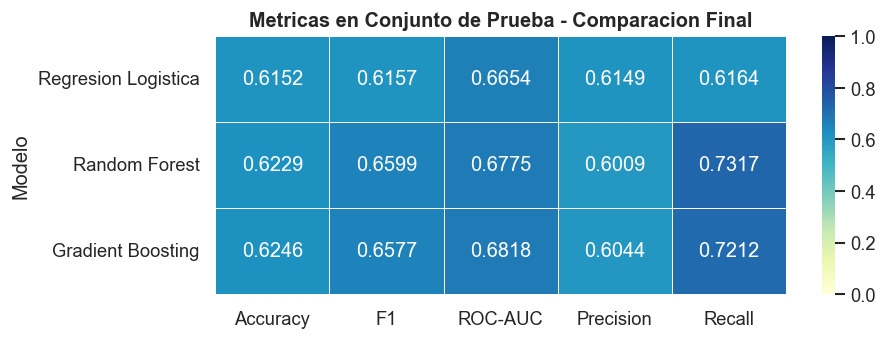

[INFO] Figura guardada: ../reports/figures/metrics_heatmap.png


In [5]:
plot_metrics_heatmap(test_results, save_path=f'{FIGURES_DIR}/metrics_heatmap.png')

## 5.2 Matrices de confusión

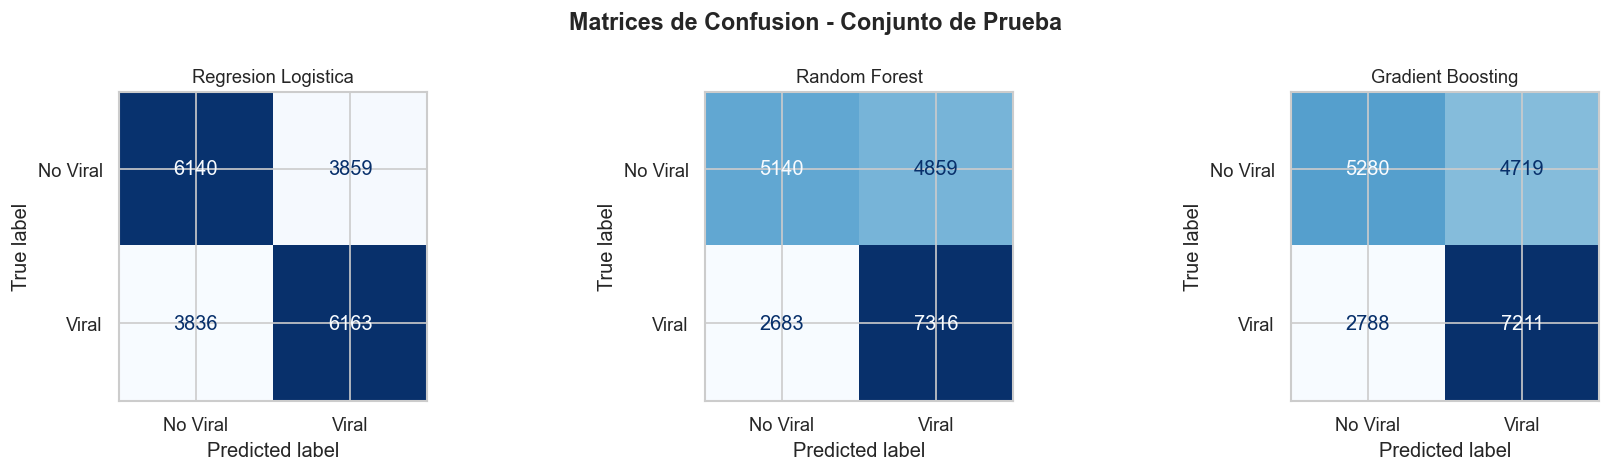

[INFO] Figura guardada: ../reports/figures/confusion_matrices.png


In [6]:
plot_confusion_matrices(trained_models, X_test_proc, y_test.values,
                         save_path=f'{FIGURES_DIR}/confusion_matrices.png')

## 5.3 Curvas ROC

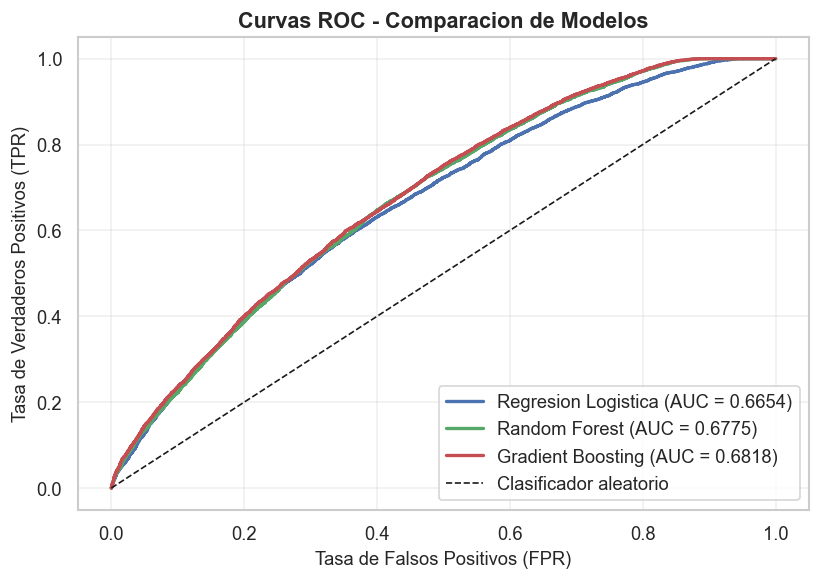

[INFO] Figura guardada: ../reports/figures/roc_curves.png


In [7]:
plot_roc_curves(trained_models, X_test_proc, y_test.values,
                save_path=f'{FIGURES_DIR}/roc_curves.png')

## 5.4 Importancia de caracteristicas

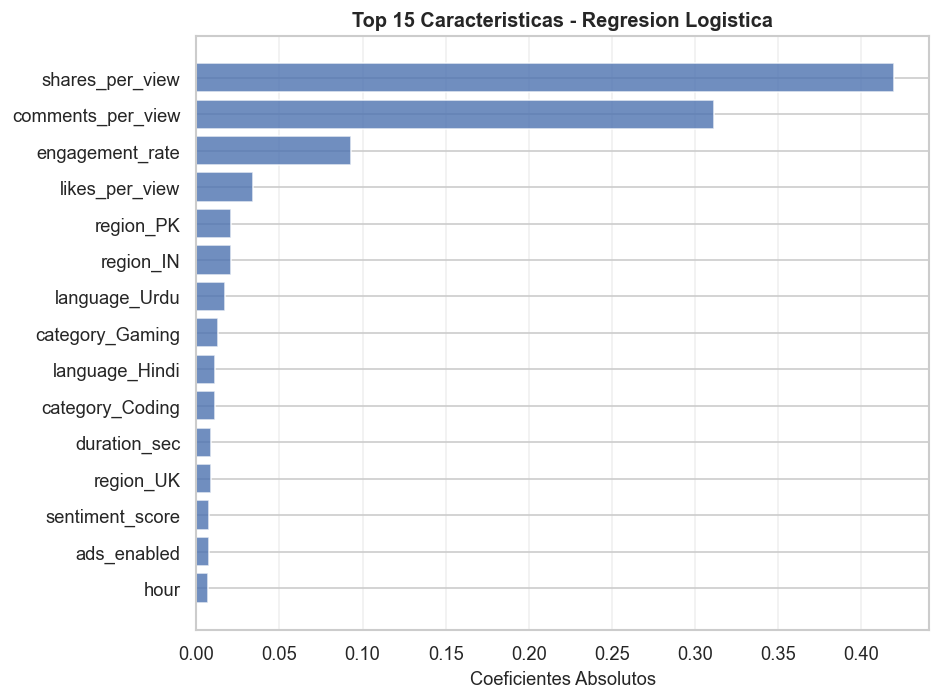

[INFO] Figura guardada: ../reports/figures/feature_importance_regresion_logistica.png


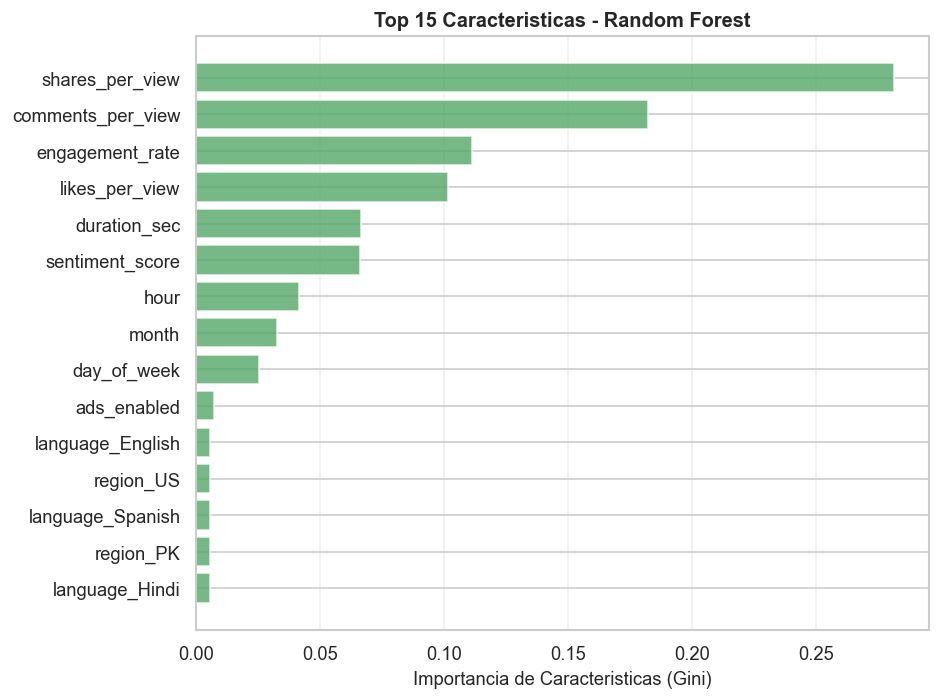

[INFO] Figura guardada: ../reports/figures/feature_importance_random_forest.png


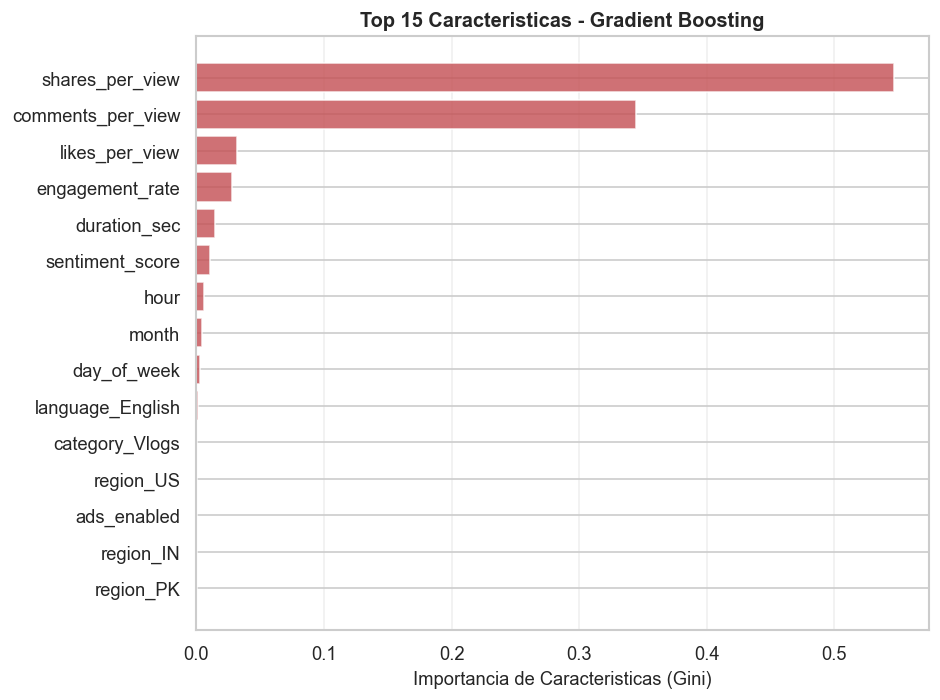

[INFO] Figura guardada: ../reports/figures/feature_importance_gradient_boosting.png


In [8]:
for name, model in trained_models.items():
    plot_feature_importance(
        model, feature_names_proc, name, top_n=15,
        save_path=f'{FIGURES_DIR}/feature_importance.png'
    )

## 5.5 Comparación global y selección del mejor modelo

In [9]:
# Comparacion: CV vs Test
summary = pd.DataFrame({
    'CV ROC-AUC': cv_results['ROC-AUC (val)'],
    'Test ROC-AUC': test_results['ROC-AUC'],
    'CV F1': cv_results['F1 (val)'],
    'Test F1': test_results['F1'],
    'Test Accuracy': test_results['Accuracy'],
})

print('Comparacion CV vs Conjunto de Prueba:')
display(summary.round(4))

mejor_modelo = test_results['ROC-AUC'].idxmax()
mejor_auc    = test_results.loc[mejor_modelo, 'ROC-AUC']

print(f'\nMejor modelo (por ROC-AUC en prueba): {mejor_modelo}')
print(f'ROC-AUC = {mejor_auc:.4f}')

Comparacion CV vs Conjunto de Prueba:


,CV ROC-AUC,Test ROC-AUC,CV F1,Test F1,Test Accuracy
Regresion Logistica,0.6634,0.6654,0.6127,0.6157,0.6152
Random Forest,0.6767,0.6775,0.6579,0.6599,0.6229
Gradient Boosting,0.6799,0.6818,0.6562,0.6577,0.6246



Mejor modelo (por ROC-AUC en prueba): Gradient Boosting
ROC-AUC = 0.6818


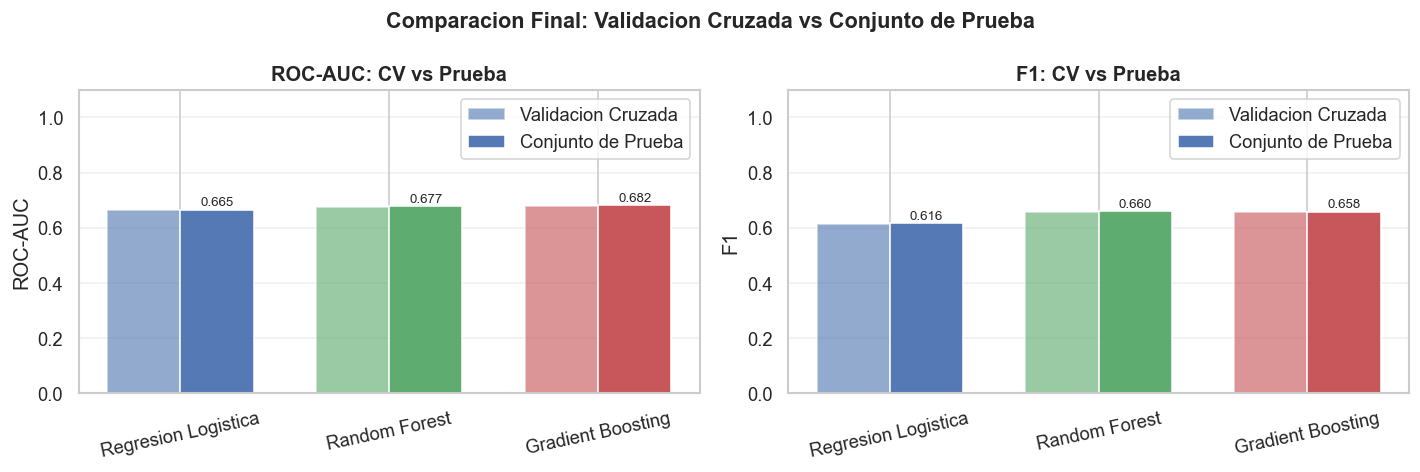

In [10]:
# Grafica de barras lado a lado: CV vs Test
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, ['ROC-AUC', 'F1']):
    cv_vals   = summary[f'CV {metric}'].values
    test_vals = summary[f'Test {metric}'].values
    x = np.arange(len(summary))
    w = 0.35

    bars1 = ax.bar(x - w/2, cv_vals,   w, label='Validacion Cruzada',
                   color=model_colors, alpha=0.6)
    bars2 = ax.bar(x + w/2, test_vals, w, label='Conjunto de Prueba',
                   color=model_colors, alpha=0.95)

    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=12)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.1)
    ax.set_title(f'{metric}: CV vs Prueba', fontweight='bold')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bar, val in zip(bars2, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparacion Final: Validacion Cruzada vs Conjunto de Prueba',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/comparacion_final.png', bbox_inches='tight')
plt.show()

In [12]:
with open(PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl', 'wb') as f:
    pickle.dump({
        'test_results': test_results,
        'mejor_modelo': mejor_modelo,
        'mejor_auc':    mejor_auc
    }, f)

print("Guardado en:", PROJECT_ROOT / 'data' / 'processed' / 'fase5_artifacts.pkl')

Guardado en: c:\Users\jespi\OneDrive - Universidad de la Sabana\PoyectoML\Proyecto_Final_ML\data\processed\fase5_artifacts.pkl
